# 2 - Baseline linéaire (régression + classification)

Le cahier des charges demande une **baseline simple** comme plancher de comparaison, et c'est
un manque de ma V1. Le principe : si un modèle avancé ne bat pas une droite, il ne sert à rien.
La baseline **quantifie** ce que les modèles suivants apportent réellement.

Deux modèles linéaires, un par tâche :

- **Régression RUL** : `LinearRegression` (moindres carrés, zéro hyperparamètre → vraie référence minimale) ;
- **Classification `at_risk`** : `LogisticRegression` avec `class_weight='balanced'` — la cible
  n'a que ~14 % de positifs (calculé au notebook 01), sans rééquilibrage le modèle apprendrait
  surtout à dire "normal".

Limite assumée : un modèle linéaire suppose que l'usure évolue en ligne droite avec les capteurs,
ce qui est faux pour une dégradation mécanique (effets de seuil, interactions entre capteurs).
C'est exactement l'écart que les arbres (03, 04) et le LSTM (05) doivent combler.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import outils_mspr as outils

## Règle d'évaluation (commune à tous les notebooks de modèles)

`outils.evaluer_et_sauver` applique la même procédure finale à tous les modèles tabulaires
(02, 03, 04) — c'est ce qui rend la synthèse honnête :

- La **validation** (20 % des machines, jamais vues) sert à contrôler le modèle avant l'examen ;
- Le **test officiel** (machines tronquées + RUL vrai) donne les métriques finales,
  prédites au **dernier cycle observé** de chaque machine (comme en V1) ;
- Les prédictions de RUL sont bornées à **[0, 125]** : un RUL négatif n'a pas de sens physique,
  et le modèle est entraîné sur une cible plafonnée à 125 donc prédire au-delà serait de
  l'extrapolation pure. (Une régression linéaire peut sortir -20 ou +160, on la ramène au domaine valide.)

## Usine 1

In [2]:
App_U1, Val_U1, Test_U1, y_rul_vrai_U1, y_risk_vrai_U1, Features_U1 = outils.preparer_usine(1)

# Normalisation MinMax [0,1] : indispensable pour un modèle linéaire (sinon les
# coefficients dépendent de l'échelle du capteur). Ajustée sur l'APPRENTISSAGE seulement.
scaler_U1 = MinMaxScaler().fit(App_U1[Features_U1])
X_app_U1 = scaler_U1.transform(App_U1[Features_U1])
X_val_U1 = scaler_U1.transform(Val_U1[Features_U1])

In [3]:
# Régression RUL
linreg_U1 = LinearRegression()
linreg_U1.fit(X_app_U1, App_U1['RUL'])

# Contrôle sur la validation (machines jamais vues, tous cycles confondus)
pred_val = np.clip(linreg_U1.predict(X_val_U1), 0, outils.RUL_MAX)
rmse_val = np.sqrt(np.mean((Val_U1['RUL'] - pred_val) ** 2))
print(f"RMSE validation : {rmse_val:.2f} cycles")

RMSE validation : 19.47 cycles


In [4]:
# Classification at_risk
logreg_U1 = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_U1.fit(X_app_U1, App_U1['at_risk'])

pred_val_risk = logreg_U1.predict(X_val_U1)
from sklearn.metrics import f1_score
print(f"F1 validation : {f1_score(Val_U1['at_risk'], pred_val_risk):.3f}")

F1 validation : 0.816


In [5]:
pred_risk_U1 = outils.evaluer_et_sauver('baseline', 1, scaler_U1, linreg_U1, logreg_U1,
                                 Features_U1, Test_U1, y_rul_vrai_U1, y_risk_vrai_U1)


===== Usine 1 — Régression RUL =====
 ---------- Resultat régression ----------
R² : 0.7044
MAE (erreur moyenne) : 18.13 cycles
RMSE (erreur écart-type) : 22.55 cycles
PHM08 Sûr (prédit trop tôt) : 517
PHM08 Dangereux (prédit trop tard) : 2821
Score NASA total : 3338  (moyen par machine : 16.69)

===== Usine 1 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.945
Precision (alertes justifiées) : 0.840
Recall (machines à risque détectées) : 0.933
F1 : 0.884
ROC-AUC : 0.986


## Usine 2

Même procédure — la seule différence est déjà dans `preparer_usine` : les capteurs de
l'Usine 2 sont normalisés **par régime** (voir notebook 01), sinon un modèle linéaire
est perdu au milieu des 6 plages de valeurs.

In [6]:
App_U2, Val_U2, Test_U2, y_rul_vrai_U2, y_risk_vrai_U2, Features_U2 = outils.preparer_usine(2)

scaler_U2 = MinMaxScaler().fit(App_U2[Features_U2])
X_app_U2 = scaler_U2.transform(App_U2[Features_U2])
X_val_U2 = scaler_U2.transform(Val_U2[Features_U2])

linreg_U2 = LinearRegression()
linreg_U2.fit(X_app_U2, App_U2['RUL'])

logreg_U2 = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_U2.fit(X_app_U2, App_U2['at_risk'])

pred_val = np.clip(linreg_U2.predict(X_val_U2), 0, outils.RUL_MAX)
print(f"RMSE validation : {np.sqrt(np.mean((Val_U2['RUL'] - pred_val) ** 2)):.2f} cycles")
print(f"F1 validation : {f1_score(Val_U2['at_risk'], logreg_U2.predict(X_val_U2)):.3f}")

RMSE validation : 20.87 cycles
F1 validation : 0.775


In [7]:
pred_risk_U2 = outils.evaluer_et_sauver('baseline', 2, scaler_U2, linreg_U2, logreg_U2,
                                 Features_U2, Test_U2, y_rul_vrai_U2, y_risk_vrai_U2)


===== Usine 2 — Régression RUL =====
 ---------- Resultat régression ----------
R² : 0.6080
MAE (erreur moyenne) : 26.39 cycles
RMSE (erreur écart-type) : 33.94 cycles
PHM08 Sûr (prédit trop tôt) : 27784
PHM08 Dangereux (prédit trop tard) : 4843
Score NASA total : 32627  (moyen par machine : 64.35)

===== Usine 2 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.909
Precision (alertes justifiées) : 0.727
Recall (machines à risque détectées) : 0.956
F1 : 0.826
ROC-AUC : 0.981


## Matrices de confusion (classification)

Pour le métier, les deux erreurs n'ont pas le même prix : une **fausse alerte** (en haut à
droite) coûte une intervention inutile, un **risque manqué** (en bas à gauche) coûte une
panne non planifiée — le pire cas pour MECHA.

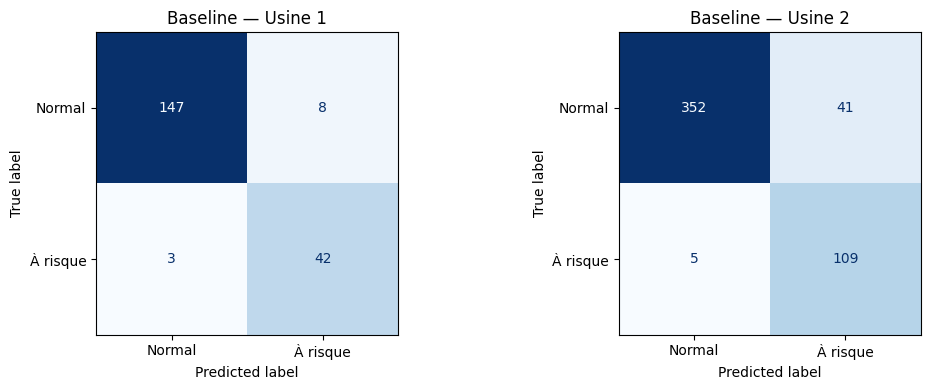

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (num, y_vrai, y_pred) in zip(axes, [(1, y_risk_vrai_U1, pred_risk_U1),
                                            (2, y_risk_vrai_U2, pred_risk_U2)]):
    cm = confusion_matrix(y_vrai, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'À risque']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Baseline — Usine {num}')
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'baseline_confusion.png', dpi=120)
plt.show()

## Lecture

- La baseline pose le **plancher** : tout modèle des notebooks suivants doit faire mieux,
  sinon sa complexité n'est pas justifiée.
- Comme attendu d'un modèle linéaire sur une dégradation mécanique, l'erreur RUL reste
  importante — c'est la marge que les modèles non linéaires doivent combler.
- Les chiffres finaux et la comparaison complète sont dans le notebook **06 - Synthèse**.